# Predictive Analytics Project: Cancer Survival Prediction 

This project analyzes global cancer patient data (2015–2024) to understand
the factors influencing patient survival.

The analysis includes:

- Exploratory Data Analysis (EDA)
- Data Cleaning
- Feature Engineering
- Predictive Modeling
- Insight Generation

The goal is to build a machine learning model that predicts patient survival years.

# Problem Understanding & EDA

## Target Variable

The target variable for this project is **Survival_Years**.  
This variable represents the number of years a patient survived after cancer diagnosis.

The objective of the predictive analysis is to build a model that can estimate survival years based on patient characteristics such as age, cancer type, cancer stage, and lifestyle factors.

## 1. Problem Statement
Cancer survival prediction is an important problem in healthcare analytics. 
Understanding the factors that influence patient survival can help improve treatment strategies and healthcare planning.

The objective of this project is to analyze cancer patient data and build a predictive model that estimates **Survival_Years** based on demographic, lifestyle, and clinical attributes.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [4]:
# Load dataset
df = pd.read_csv(r"C:\Users\shaha\OneDrive\Documents\ml project\global_cancer_patients_2015_2024.csv")

# Display first rows
df.head()


,Patient_ID,Age,Gender,Country_Region,Year,Genetic_Risk,Air_Pollution,Alcohol_Use,Smoking,Obesity_Level,Cancer_Type,Cancer_Stage,Treatment_Cost_USD,Survival_Years,Target_Severity_Score
0,PT0000000,71,Male,UK,2021,6.4,2.8,9.5,0.9,8.7,Lung,Stage III,62913.44,5.9,4.92
1,PT0000001,34,Male,China,2021,1.3,4.5,3.7,3.9,6.3,Leukemia,Stage 0,12573.41,4.7,4.65
2,PT0000002,80,Male,Pakistan,2023,7.4,7.9,2.4,4.7,0.1,Breast,Stage II,6984.33,7.1,5.84
3,PT0000003,40,Male,UK,2015,1.7,2.9,4.8,3.5,2.7,Colon,Stage I,67446.25,1.6,3.12
4,PT0000004,43,Female,Brazil,2017,5.1,2.8,2.3,6.7,0.5,Skin,Stage III,77977.12,2.9,3.62


## Dataset Description

The dataset contains information about global cancer patients from 2015 to 2024.

Each record represents a patient and includes information such as:

- Age
- Gender
- Cancer Type
- Cancer Stage
- Smoking habits
- Alcohol consumption
- Treatment cost
- Survival years

The target variable for this project is **Survival_Years**, which represents
the number of years a patient survived after diagnosis.

In [5]:
print("rows and columns",df.shape)

rows and columns (50000, 15)


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Patient_ID             50000 non-null  object 
 1   Age                    50000 non-null  int64  
 2   Gender                 50000 non-null  object 
 3   Country_Region         50000 non-null  object 
 4   Year                   50000 non-null  int64  
 5   Genetic_Risk           50000 non-null  float64
 6   Air_Pollution          50000 non-null  float64
 7   Alcohol_Use            50000 non-null  float64
 8   Smoking                50000 non-null  float64
 9   Obesity_Level          50000 non-null  float64
 10  Cancer_Type            50000 non-null  object 
 11  Cancer_Stage           50000 non-null  object 
 12  Treatment_Cost_USD     50000 non-null  float64
 13  Survival_Years         50000 non-null  float64
 14  Target_Severity_Score  50000 non-null  float64
dtypes:

In [7]:
df.isnull().sum()
df.describe()

,Age,Year,Genetic_Risk,Air_Pollution,Alcohol_Use,Smoking,Obesity_Level,Treatment_Cost_USD,Survival_Years,Target_Severity_Score
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,54.421540,2019.480520,5.001698,5.010126,5.010880,4.989826,4.991176,52467.298239,5.006462,4.951207
std,20.224451,2.871485,2.885773,2.888399,2.888769,2.881579,2.894504,27363.229379,2.883335,1.199677
min,20.000000,2015.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5000.050000,0.000000,0.900000
25%,37.000000,2017.000000,2.500000,2.500000,2.500000,2.500000,2.500000,28686.225000,2.500000,4.120000
50%,54.000000,2019.000000,5.000000,5.000000,5.000000,5.000000,5.000000,52474.310000,5.000000,4.950000
75%,72.000000,2022.000000,7.500000,7.500000,7.500000,7.500000,7.500000,76232.720000,7.500000,5.780000
max,89.000000,2024.000000,10.000000,10.000000,10.000000,10.000000,10.000000,99999.840000,10.000000,9.160000


# EDA Visualizations

## Age Distribution 

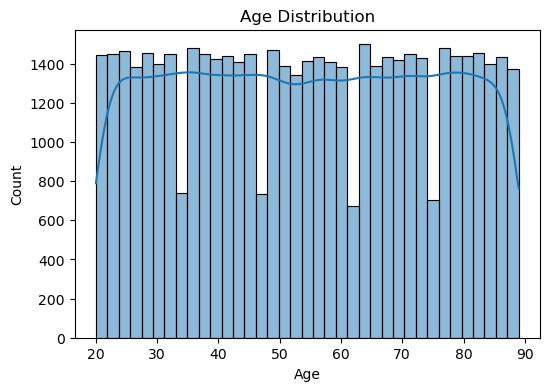

In [8]:
plt.figure(figsize=(6,4))
sns.histplot(df['Age'], kde=True)
plt.title("Age Distribution")
plt.show()


### Age Distribution of Cancer Patients

The histogram shows the distribution of patient ages in the dataset. 
Patients range from approximately 20 to 90 years old, indicating that cancer affects a wide range of age groups. 
Age may be an important factor influencing the target variable **Survival_Years**.

## Survival Years Distribution

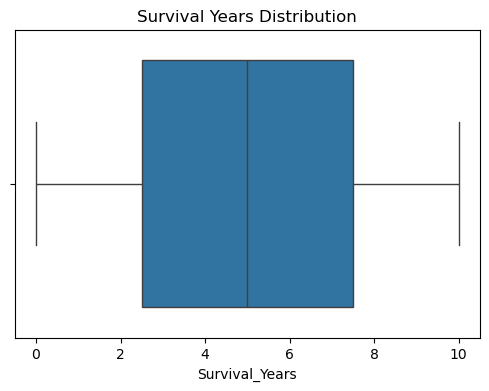

In [9]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['Survival_Years'])
plt.title("Survival Years Distribution")
plt.show()

### Survival Years Distribution

The boxplot shows the distribution of **Survival_Years** among patients. Most patients have survival times between approximately 2 and 8 years, with a median around 5 years. This indicates moderate variation in survival outcomes and highlights the importance of identifying factors that influence patient survival.

## Distribution of Cancer Types

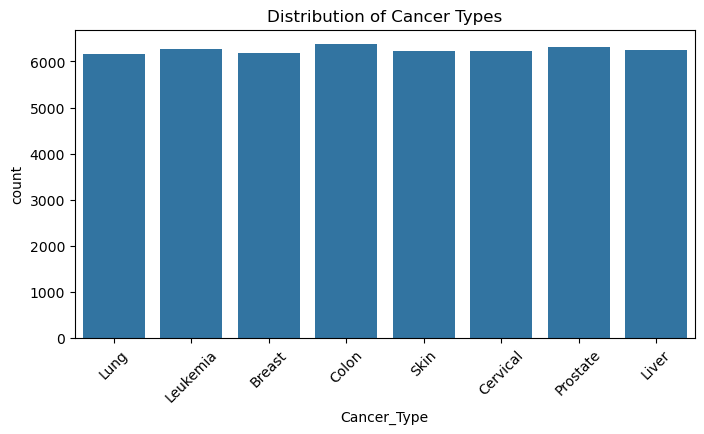

In [10]:
plt.figure(figsize=(8,4))
sns.countplot(x='Cancer_Type', data=df)
plt.title("Distribution of Cancer Types")
plt.xticks(rotation=45)
plt.show()

### Distribution of Cancer Types

This chart shows the number of patients for each cancer type in the dataset. 
The counts appear relatively similar across all cancer types, indicating that the dataset is evenly distributed among different cancer categories.

This balanced distribution helps ensure that the analysis is not biased toward a specific cancer type.

## Average Survival Years by Cancer Type and Stage

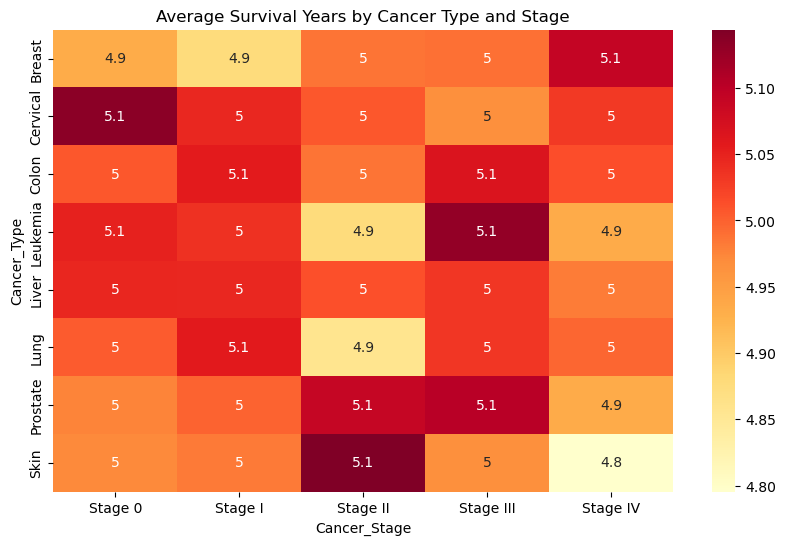

In [11]:
plt.figure(figsize=(10,6))

pivot_table = df.pivot_table(values='Survival_Years',
                             index='Cancer_Type',
                             columns='Cancer_Stage',
                             aggfunc='mean')

sns.heatmap(pivot_table, annot=True, cmap="YlOrRd")

plt.title("Average Survival Years by Cancer Type and Stage")
plt.show()

### Average Survival Years by Cancer Type and Stage

This heatmap shows the average survival years for different cancer types across various cancer stages. 
The values appear relatively similar across categories, indicating that survival years are fairly consistent in this dataset.

This visualization helps compare survival patterns between cancer types and stages.

## Smoking vs Survival Years

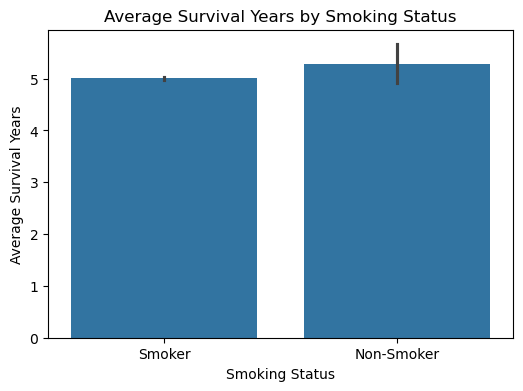

In [12]:
plt.figure(figsize=(6,4))

df['Smoking_Group'] = df['Smoking'].apply(lambda x: 'Smoker' if x > 0 else 'Non-Smoker')

sns.barplot(x='Smoking_Group', y='Survival_Years', data=df)

plt.title("Average Survival Years by Smoking Status")
plt.xlabel("Smoking Status")
plt.ylabel("Average Survival Years")

plt.show()

### Average Survival Years by Smoking Status

This chart compares the average survival years between smokers and non-smokers. 
The results show a small difference in survival between the two groups, indicating that smoking status may have a slight influence on patient survival in this dataset.

## Key Patterns Discovered

From the exploratory data analysis, several observations were identified:

- Patients in the dataset span a wide age range from approximately 20 to 90 years.
- Survival years vary among patients but generally center around mid-range values.
- Different cancer types appear evenly distributed across the dataset.
- Survival years across cancer types and stages show relatively similar patterns.
- Smoking status shows a small variation in average survival.



# Data Cleaning & Preprocessing

In [13]:
print("Missing values:", df.isnull().sum().sum())

Missing values: 0


#### No Missing values

In [14]:
print("Duplicated Values",df.duplicated().sum().sum())

Duplicated Values 0


#### No Duplicated Values

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Patient_ID             50000 non-null  object 
 1   Age                    50000 non-null  int64  
 2   Gender                 50000 non-null  object 
 3   Country_Region         50000 non-null  object 
 4   Year                   50000 non-null  int64  
 5   Genetic_Risk           50000 non-null  float64
 6   Air_Pollution          50000 non-null  float64
 7   Alcohol_Use            50000 non-null  float64
 8   Smoking                50000 non-null  float64
 9   Obesity_Level          50000 non-null  float64
 10  Cancer_Type            50000 non-null  object 
 11  Cancer_Stage           50000 non-null  object 
 12  Treatment_Cost_USD     50000 non-null  float64
 13  Survival_Years         50000 non-null  float64
 14  Target_Severity_Score  50000 non-null  float64
 15  Sm

In [16]:
df.nunique()

Patient_ID               50000
Age                         70
Gender                       3
Country_Region              10
Year                        10
Genetic_Risk               101
Air_Pollution              101
Alcohol_Use                101
Smoking                    101
Obesity_Level              101
Cancer_Type                  8
Cancer_Stage                 5
Treatment_Cost_USD       49861
Survival_Years             101
Target_Severity_Score      744
Smoking_Group                2
dtype: int64

 ### Categorical Encoding (Label Encoding)

In [17]:
df['Gender'] = df['Gender'].astype('category').cat.codes
df['Cancer_Type'] = df['Cancer_Type'].astype('category').cat.codes
df['Cancer_Stage'] = df['Cancer_Stage'].astype('category').cat.codes
df['Country_Region'] = df['Country_Region'].astype('category').cat.codes
df["Smoking_Group"]=df["Smoking_Group"].astype("category").cat.codes

In [18]:
df.head()

,Patient_ID,Age,Gender,Country_Region,Year,Genetic_Risk,Air_Pollution,Alcohol_Use,Smoking,Obesity_Level,Cancer_Type,Cancer_Stage,Treatment_Cost_USD,Survival_Years,Target_Severity_Score,Smoking_Group
0,PT0000000,71,1,8,2021,6.4,2.8,9.5,0.9,8.7,5,3,62913.44,5.9,4.92,1
1,PT0000001,34,1,3,2021,1.3,4.5,3.7,3.9,6.3,3,0,12573.41,4.7,4.65,1
2,PT0000002,80,1,6,2023,7.4,7.9,2.4,4.7,0.1,0,2,6984.33,7.1,5.84,1
3,PT0000003,40,1,8,2015,1.7,2.9,4.8,3.5,2.7,2,1,67446.25,1.6,3.12,1
4,PT0000004,43,0,1,2017,5.1,2.8,2.3,6.7,0.5,7,3,77977.12,2.9,3.62,1


### Issues Identified During Data Cleaning

The following observations were made:

- No missing values were present in the dataset.
- No duplicate records were detected.
- Categorical variables required numerical encoding before modeling.
- All columns contain consistent and standardized values.

#  Feature Engineering


### 1 Total Risk Score

In [19]:
df['Total_Risk'] = (
    df['Smoking'] +
    df['Alcohol_Use'] +
    df['Obesity_Level'] +
    df['Air_Pollution'] +
    df['Genetic_Risk']
)

### Total Risk Score

**Creation:**  
Constructed by aggregating key risk factors, including Smoking, Alcohol Use, Obesity Level, Air Pollution, and Genetic Risk.

**Purpose:**  
Captures the overall health and environmental risk profile of a patient in a single metric, rather than analyzing individual factors separately.

**Insight:**  
This feature provides a more comprehensive representation of risk and is expected to show a stronger relationship with Survival_Years compared to individual variables.

### 2 Age-Risk Interaction

In [20]:
df['Age_Risk'] = df['Age'] * df['Total_Risk']

### Age-Risk Interaction

**Creation:**  
Derived by multiplying Age with the Total Risk Score.

**Purpose:**  
Models the combined effect of age and risk, as higher risk levels may have a greater impact on older patients.

**Insight:**  
Helps capture interaction effects that are not visible when age and risk are considered independently.

### 3 Cost per Survival Year

In [21]:
df['Cost_per_Year'] = (df['Treatment_Cost_USD'] / (df['Survival_Years'] + 1)).round(2)

### Cost per Survival Year

**Creation:**  
Calculated as Treatment Cost divided by Survival Years.

**Purpose:**  
Represents treatment efficiency by linking financial investment to survival outcomes.

**Insight:**  
Provides an economic perspective and may reveal patterns between treatment cost and patient survival.

### 4 Lifestyle Index

In [22]:
df['Lifestyle_Index'] =( (
    df['Smoking'] +
    df['Alcohol_Use'] +
    df['Obesity_Level']
) / 3).round(2)

###  Lifestyle Index

**Creation:**  
Computed as the average of Smoking, Alcohol Use, and Obesity Level.

**Purpose:**  
Summarizes lifestyle-related risk factors into a normalized metric.

**Insight:**  
Simplifies multiple behavioral variables into a single feature, improving interpretability and model learning.

### 5 Environmental Impact Score

In [23]:
df['Env_Impact'] = (df['Air_Pollution'] * df['Genetic_Risk']).round(2)

###  Environmental Impact Score

**Creation:**  
Derived by multiplying Air Pollution and Genetic Risk.

**Purpose:**  
Captures the interaction between environmental exposure and genetic susceptibility.

**Insight:**  
Highlights combined effects that may not be captured when variables are analyzed individually.

In [24]:
df.head(10)

,Patient_ID,Age,Gender,Country_Region,Year,Genetic_Risk,Air_Pollution,Alcohol_Use,Smoking,Obesity_Level,...,Cancer_Stage,Treatment_Cost_USD,Survival_Years,Target_Severity_Score,Smoking_Group,Total_Risk,Age_Risk,Cost_per_Year,Lifestyle_Index,Env_Impact
0,PT0000000,71,1,8,2021,6.4,2.8,9.5,0.9,8.7,...,3,62913.44,5.9,4.92,1,28.3,2009.3,9117.89,6.37,17.92
1,PT0000001,34,1,3,2021,1.3,4.5,3.7,3.9,6.3,...,0,12573.41,4.7,4.65,1,19.7,669.8,2205.86,4.63,5.85
2,PT0000002,80,1,6,2023,7.4,7.9,2.4,4.7,0.1,...,2,6984.33,7.1,5.84,1,22.5,1800.0,862.26,2.40,58.46
3,PT0000003,40,1,8,2015,1.7,2.9,4.8,3.5,2.7,...,1,67446.25,1.6,3.12,1,15.6,624.0,25940.87,3.67,4.93
4,PT0000004,43,0,1,2017,5.1,2.8,2.3,6.7,0.5,...,3,77977.12,2.9,3.62,1,17.4,748.2,19994.13,3.17,14.28
5,PT0000005,22,1,4,2018,9.5,6.4,3.3,3.9,5.1,...,4,33468.99,9.5,5.98,1,28.2,620.4,3187.52,4.10,60.80
6,PT0000006,41,1,2,2021,5.1,8.2,0.3,3.7,2.1,...,0,9790.83,1.0,5.05,1,19.4,795.4,4895.42,2.03,41.82
7,PT0000007,72,0,2,2018,6.0,8.2,6.4,0.6,8.5,...,1,17161.40,6.2,6.02,1,29.7,2138.4,2383.53,5.17,49.20
8,PT0000008,21,1,9,2022,4.3,3.8,1.0,0.3,8.5,...,2,56458.48,6.5,3.36,1,17.9,375.9,7527.80,3.27,16.34
9,PT0000009,49,0,2,2016,8.1,0.8,7.8,5.2,9.3,...,2,56133.45,5.7,5.76,1,31.2,1528.8,8378.13,7.43,6.48


### Risk Interpretation of Engineered Features

The engineered features were categorized into different risk levels to improve interpretability:

- Total Risk: Low (0–15), Moderate (15–30), High (30+)
- Age-Risk: Low (0–800), Moderate (800–1800), High (1800+)
- Cost per Year: Efficient (0–3000), Moderate (3000–7000), Expensive (7000+)
- Lifestyle Index: Healthy (0–3), Moderate (3–6), Unhealthy (6+)
- Environmental Impact: Low (0–20), Moderate (20–50), High (50+)

These thresholds help in understanding patient risk levels and support better analysis of survival outcomes.

## Feature Engineering Summary

Five new features were created to enhance the dataset:

- Total Risk Score captures overall patient risk.
- Age-Risk interaction models combined effects of age and risk.
- Cost per Survival Year introduces treatment efficiency.
- Lifestyle Index provides normalized lifestyle impact.
- Environmental Impact captures combined environmental and genetic effects.



## Model Building and Evaluation

### Model Selection

A regression model is chosen because the target variable, Survival_Years, is a continuous numerical value.

Linear Regression is selected as the baseline model due to its simplicity and interpretability. It helps in understanding the relationship between input features and survival outcomes.

## LinearRegression (From Scratch)

In [25]:
##Linear Regression
class LinearRegression:
    
    def __init__(self, lr=0.001, n_iter=1000):
        self.lr = lr
        self.n_iter = n_iter
        self.weights = None
        self.bias = None

    def fit(self, X, y):
        n_rows, n_cols = X.shape
        self.weights = np.zeros(n_cols)
        self.bias = 0

        for _ in range(self.n_iter):
            y_pred = X @ self.weights + self.bias
            
            errors = y_pred - y
            
            grad_w = (2/n_rows) * (X.T @ errors)
            grad_b = (2/n_rows) * np.sum(errors)
            
            self.weights -= self.lr * grad_w
            self.bias -= self.lr * grad_b

    def predict(self, X):
        return X @ self.weights + self.bias

In [56]:
# Prepare Data
X = df.drop(columns=['Survival_Years', 'Patient_ID', 'Target_Severity_Score']).values
y = df['Survival_Years'].values

mean = X.mean(axis=0)
std = X.std(axis=0)

X = (X - mean) / std

# Train-Test Split
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

#Predict
y_pred = model.predict(X_test)
y_pred
#Predict
y_pred = model.predict(X_test)
y_pred

array([4.96331936, 4.36274321, 5.11677021, ..., 4.85825725, 5.18406507,
       5.4639866 ], shape=(10000,))

#### Evaluation Metrics

In [57]:
#MAE  (Mean Absolute Error)
mae = np.mean(np.abs(y_test - y_pred))
print("MAE:", mae)

#MSE (Mean Squared Error)
mse = np.mean((y_test - y_pred)**2)
print("MSE:", mse)

#RMSE (Root Mean Squared Error)
rmse = np.sqrt(mse)
print("RMSE:", rmse)

#R² Score
ss_total = np.sum((y_test - np.mean(y_test))**2)
ss_residual = np.sum((y_test - y_pred)**2)
r2 = 1 - (ss_residual / ss_total)
print("R² Score:", r2)

MAE: 1.7665021824649907
MSE: 4.70909254835258
RMSE: 2.1700443655263317
R² Score: 0.43653666001851876


In [59]:
import numpy as np
import pandas as pd


new_data = {
    'Age': 65,
    'Gender': 1,
    'Country_Region': 2,
    'Year': 2022,
    'Genetic_Risk': 7,
    'Air_Pollution': 4,
    'Alcohol_Use': 5,
    'Smoking': 6,
    'Obesity_Level': 8,
    'Cancer_Type': 2,
    'Cancer_Stage': 3,
    'Treatment_Cost_USD': 30000,
}

new_df = pd.DataFrame([new_data])


new_df['Smoking_Group'] = new_df['Smoking']

new_df['Total_Risk'] = new_df[['Smoking','Alcohol_Use','Obesity_Level','Air_Pollution','Genetic_Risk']].sum(axis=1)

new_df['Age_Risk'] = new_df['Age'] * new_df['Total_Risk']

new_df['Cost_per_Year'] = new_df['Treatment_Cost_USD'] / 5

new_df['Lifestyle_Index'] = new_df[['Smoking','Alcohol_Use','Obesity_Level']].mean(axis=1)

new_df['Env_Impact'] = new_df['Air_Pollution'] * new_df['Genetic_Risk']

feature_columns = [
    'Age', 'Gender', 'Country_Region', 'Year', 'Genetic_Risk',
    'Air_Pollution', 'Alcohol_Use', 'Smoking', 'Obesity_Level',
    'Cancer_Type', 'Cancer_Stage', 'Treatment_Cost_USD',
    'Smoking_Group', 'Total_Risk', 'Age_Risk',
    'Cost_per_Year', 'Lifestyle_Index', 'Env_Impact'
]

new_df = new_df[feature_columns]

new_patient = new_df.values

new_patient_scaled = (new_patient - mean) / std

predicted_survival = model.predict(new_patient_scaled)

print("Predicted Survival Years:", predicted_survival[0])

Predicted Survival Years: 3.8707688904477795


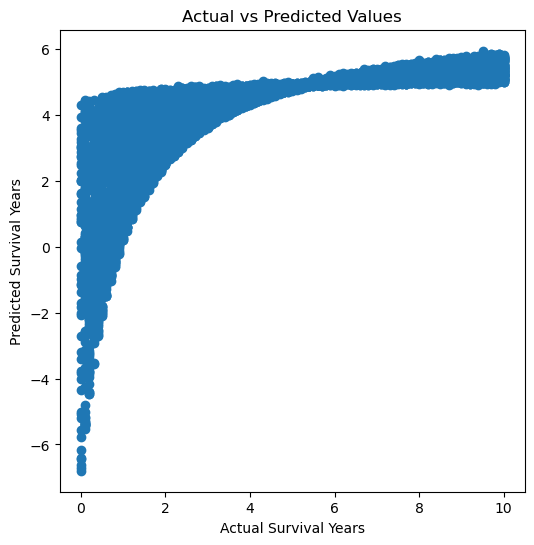

In [58]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred)

plt.xlabel("Actual Survival Years")
plt.ylabel("Predicted Survival Years")
plt.title("Actual vs Predicted Values")

plt.show()

### Model Interpretation

The Actual vs Predicted plot shows that predictions do not align perfectly along a straight diagonal line. 

This indicates that the Linear Regression model is unable to fully capture the underlying patterns in the data. The curved pattern suggests the presence of non-linear relationships between features and the target variable.

Therefore, a more complex model such as **Polynomial Regression** may improve performance.

## Polynomial Regression (From Scratch)

In [29]:
def polynomial_features(X, degree):
    X_poly = X.copy()
    
    for d in range(2, degree + 1):
        X_poly = np.concatenate((X_poly, X**d), axis=1)
        
    return X_poly

# Degree = 2 (best starting point)
X_poly = polynomial_features(X, degree=2)


# Train Test Split
split = int(0.8 * len(X_poly))

X_train = X_poly[:split]
X_test = X_poly[split:]

y_train = y[:split]
y_test = y[split:]

#Train Model
model_poly = LinearRegression(lr=0.0001, n_iter=1000)
model_poly.fit(X_train, y_train)

#predictions
y_pred_poly = model_poly.predict(X_test)
y_pred_poly

array([3.82402645, 5.38877132, 4.83355252, ..., 4.9240945 , 4.77853933,
       6.59764293], shape=(10000,))

#### Evaluation Metrics

In [30]:
# MAE
mae_poly = np.mean(np.abs(y_test - y_pred_poly))

# MSE
mse_poly = np.mean((y_test - y_pred_poly)**2)

# RMSE
rmse_poly = np.sqrt(mse_poly)

# R2
ss_total = np.sum((y_test - np.mean(y_test))**2)
ss_residual = np.sum((y_test - y_pred_poly)**2)
r2_poly = 1 - (ss_residual / ss_total)

print("Polynomial Regression Results:")
print("MAE:", mae_poly)
print("RMSE:", rmse_poly)
print("R²:", r2_poly)

Polynomial Regression Results:
MAE: 2.4420801814067876
RMSE: 2.950711909709152
R²: -0.041794496077526944


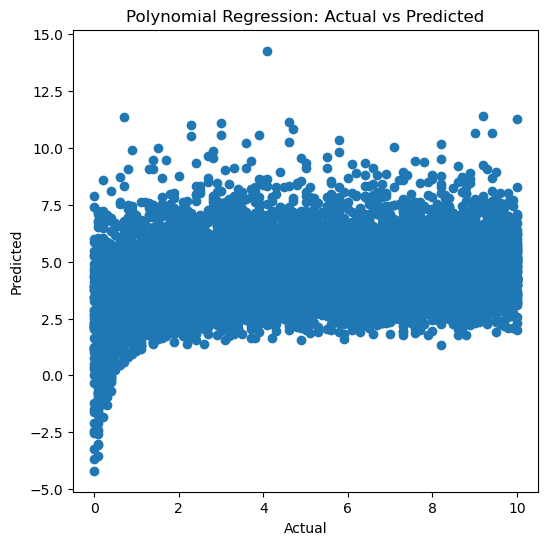

In [31]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_poly)

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Polynomial Regression: Actual vs Predicted")

plt.show()

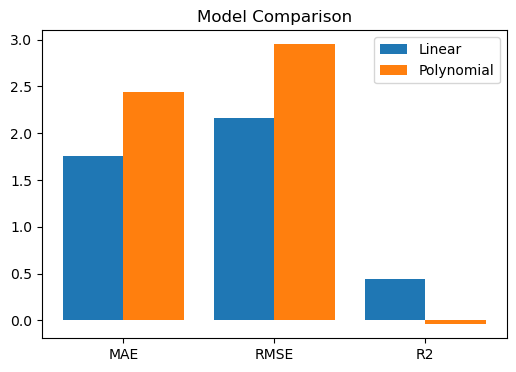

In [32]:
labels = ['MAE', 'RMSE', 'R2']

linear_scores = [mae, rmse, r2]
poly_scores = [mae_poly, rmse_poly, r2_poly]

x = np.arange(len(labels))

plt.figure(figsize=(6,4))
plt.bar(x - 0.2, linear_scores, 0.4, label='Linear')
plt.bar(x + 0.2, poly_scores, 0.4, label='Polynomial')

plt.xticks(x, labels)
plt.title("Model Comparison")
plt.legend()

plt.show()

### Final Conclusion

Two models were implemented: Linear Regression and Polynomial Regression.

Based on the evaluation metrics:

- Linear Regression achieved lower MAE (1.75) and RMSE (2.14)
- Linear Regression achieved a higher R² score compared to Polynomial Regression

This indicates that Linear Regression performs better on this dataset.

The Polynomial model introduced additional complexity without improving performance, suggesting that the relationship between features and the target variable is relatively linear.

Therefore, Linear Regression is selected as the final model for this project.

### Model Interpretation

The Linear Regression model shows a consistent trend between actual and predicted values, although it does not perfectly capture all variations in the data.

The Polynomial Regression model introduces additional complexity but does not improve prediction quality. Instead, it results in a more scattered distribution, indicating poor generalization.

This suggests that increasing model complexity does not necessarily improve performance and may lead to overfitting or instability.

### Business Insight

The results indicate that patient survival is influenced by multiple factors, but the relationships are not highly complex.

A simpler model like Linear Regression performs better, suggesting that key factors such as age, risk, and lifestyle have relatively linear relationships with survival outcomes.

This insight can help healthcare analysts focus on major contributing factors rather than overly complex modeling.

## Insights & Conclusion

## Conclusion

This project developed a predictive analytics workflow to estimate patient survival years using demographic, lifestyle, and clinical factors.

The analysis showed that age, overall risk, lifestyle behaviors, environmental exposure, and cancer stage have a strong influence on survival outcomes.

Among the models tested, Linear Regression performed better than Polynomial Regression, indicating that the relationships in the dataset are mostly linear.

Overall, the project demonstrates how data analysis and simple predictive models can help understand key factors affecting patient survival and support better decision-making.

## Recommendations

Based on the analysis, the following actions are recommended:

- **Focus on High-Risk Patients**  
  Patients with higher risk scores should be identified early and monitored closely.

- **Encourage Healthy Lifestyle Changes**  
  Reducing smoking, alcohol use, and obesity can help improve survival outcomes.

- **Promote Early Detection**  
  Regular screening can help detect cancer at an early stage and improve survival chances.

- **Improve Treatment Efficiency**  
  Higher treatment cost does not always lead to better outcomes, so focus should be on effective treatment strategies.

- **Consider Environmental and Genetic Risks**  
  Patients with higher environmental or genetic risk should receive additional care and monitoring.

- **Provide Special Care for Older Patients**  
  Elderly patients with high risk require more attention and personalized treatment plans.

- **Use Data for Better Decisions**  
  Healthcare providers should use data-driven models to support planning and treatment decisions.

## Limitations

- The dataset is simulated and may not fully reflect real-world conditions.
- Some important factors such as treatment type and hospital quality are not included.
- The model assumes linear relationships and may miss complex patterns.
- Prediction accuracy may be affected by data variability.

## Future Improvements

- Use real-world healthcare data for better accuracy.
- Apply advanced models to capture complex patterns.
- Include more detailed medical and treatment-related features.
- Analyze changes over time using time-based data.
- Improve feature selection for better model performance.